## Path configuration

In [5]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import load_config
from utils.data import load_pkl

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.utils import resample

## Data loading

In [7]:
cfg = load_config()
rki_pkl = cfg["data"]["RKI_PKL"]

In [8]:
rki = load_pkl(rki_pkl)

In [9]:
data, label, meta = rki["data"], rki["label"], rki["meta"]

In [10]:
meta = pd.DataFrame.from_records(list(meta))

## PCA

Normalize each spectrum

In [12]:
# axis=1 to work row by row
# keepdims=True keeps the dimensions needed for per-row normalization to work correctly
data_norm = (data - data.min(axis=1, keepdims=True)) / (
    data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)

Reduce dimensionality (there are 6000 features)

In [13]:
my_pca = PCA().fit(data_norm)

In [14]:
# explained_variance_ returns the amount of variance explained by each of the selected components
# explained_variance_ratio_ returnd the percentage of variance explained by each of the selected components
cumulative_explained_var = np.cumsum(my_pca.explained_variance_)
cumulative_explained_var_ratio = np.cumsum(my_pca.explained_variance_ratio_)

In [15]:
print(cumulative_explained_var)
print(cumulative_explained_var_ratio)

[17.60917665 28.53206702 35.7636226  39.47298174 42.5736215  44.47031579
 46.01041231 47.33270485 48.50193469 49.56345535 50.60659749 51.5775746
 52.32858501 53.03089626 53.67618948 54.30510513 54.89948724 55.44971122
 55.97334935 56.45804627 56.90600892 57.32262368 57.73418639 58.12514724
 58.49799114 58.85082743 59.19936914 59.52895214 59.8534658  60.16671593
 60.46974081 60.77160413 61.06369472 61.34293937 61.60711972 61.86674807
 62.11962122 62.36060606 62.59931773 62.82876253 63.05376577 63.27794853
 63.50026053 63.71595494 63.92528808 64.13273304 64.32473677 64.51310392
 64.69519906 64.87254434 65.04914136 65.22031128 65.38986172 65.55483367
 65.71438419 65.87243697 66.02154482 66.1669011  66.31060205 66.4500855
 66.58605356 66.71997681 66.85182321 66.98203301 67.11116367 67.23823606
 67.36088498 67.48238024 67.60049764 67.71540118 67.82962218 67.93984807
 68.04855117 68.1545349  68.25851864 68.3622072  68.46422781 68.56490592
 68.66360204 68.76164662 68.85847445 68.95418682 69.0

Text(0, 0.5, 'Cumulative explained variance')

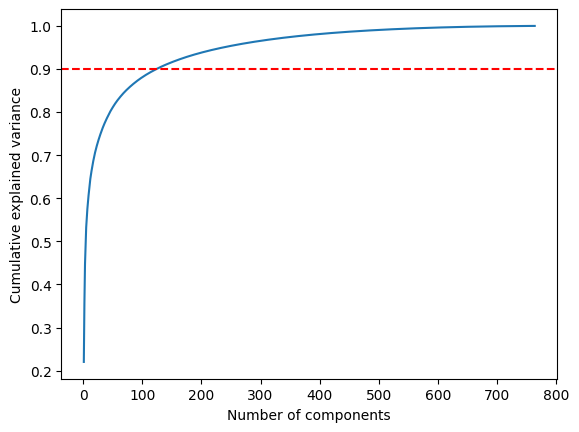

In [16]:
plt.plot(np.arange(1, len(cumulative_explained_var_ratio)+1), cumulative_explained_var_ratio)
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

In [17]:
n_components = np.argmax(cumulative_explained_var_ratio >= 0.9) + 1
print(f"Number of components explaining 90% variance: {n_components}")

Number of components explaining 90% variance: 124


This indicates that 124 components are needed to account for 90% of the variance in our dataset

In [18]:
data_norm_pca = PCA(n_components=124).fit_transform(data_norm)

## t-SNE

In [19]:
my_tsne = TSNE(n_components=2)
data_tsne = my_tsne.fit_transform(data_norm_pca)

## Visualization

### Label Encoding & DataFrame Creation  

In [44]:
# Identify unique labels
unique_labels = np.unique(label)
print(unique_labels)

# Assign a number to each label
label_to_idx = {}
for i in range(len(unique_labels)):
    label_to_idx[str(unique_labels[i])] = i
print(label_to_idx)

# Map label dataset 
encoded_label = np.array([label_to_idx[l] for l in label])

['Enterobacter_cloacae_complex' 'Enterococcus_Faecium' 'Escherichia_Coli'
 'Klebsiella_Pneumoniae' 'Pseudomonas_Aeruginosa' 'Staphylococcus_Aureus']
{'Enterobacter_cloacae_complex': 0, 'Enterococcus_Faecium': 1, 'Escherichia_Coli': 2, 'Klebsiella_Pneumoniae': 3, 'Pseudomonas_Aeruginosa': 4, 'Staphylococcus_Aureus': 5}


In [23]:
# Create a DataFrame combining coordinates and metadata
tsne_df = pd.DataFrame({
    "x": data_tsne[:, 0],
    "y": data_tsne[:, 1],
    "species": label,
})

tsne_df

,x,y,species
0,-6.715081,5.608732,Enterobacter_cloacae_complex
1,-4.367587,4.159745,Enterobacter_cloacae_complex
2,-4.554792,5.274471,Enterobacter_cloacae_complex
3,-6.659667,0.439424,Enterobacter_cloacae_complex
4,-6.488172,0.269610,Enterobacter_cloacae_complex
...,...,...,...
759,4.492241,-43.978180,Pseudomonas_Aeruginosa
760,2.461132,-44.371864,Pseudomonas_Aeruginosa
761,9.257809,-42.175751,Pseudomonas_Aeruginosa
762,8.035379,-42.651165,Pseudomonas_Aeruginosa


### Palettes and Label Orders

In [25]:
# Define categorical orders
species_sorted = sorted(tsne_df["species"].unique())

# Base palette
tab10 = sns.color_palette("tab10")

# Species palette
species_color_map = {
    "Enterobacter_cloacae_complex": tab10[5],  
    "Enterococcus_Faecium": tab10[4],         
    "Escherichia_Coli": tab10[2],             
    "Klebsiella_Pneumoniae": tab10[3],         
    "Pseudomonas_Aeruginosa": tab10[0],       
    "Staphylococcus_Aureus": tab10[1],         
}
species_palette_dict = {sp: species_color_map[sp] for sp in species_sorted}

### Global t-SNE — Visualization by Species

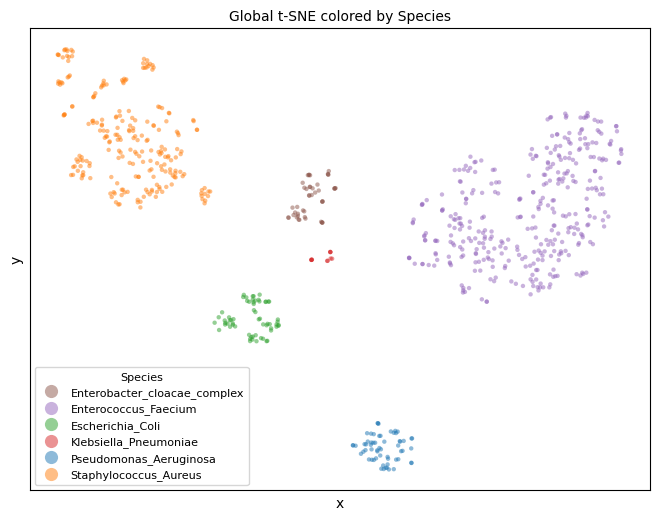

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df, x="x", y="y",
    hue="species", hue_order=species_sorted,
    palette=species_palette_dict,
    s=10, linewidth=0, ax=ax, alpha=0.5
)
ax.set_title("Global t-SNE colored by Species", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", title="Species", title_fontsize=8, fontsize=8, markerscale=3)
plt.show()